In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
DATASET_ROOT = "/content/drive/MyDrive/nsynth-test"
AUDIO_PATH = DATASET_ROOT + "/audio"
JSON_PATH = DATASET_ROOT + "/examples.json"


In [3]:
import os
import json
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import random


In [4]:
!tar -xvzf /content/drive/MyDrive/nsynth-test.jsonwav.tar.gz -C /content/drive/MyDrive


nsynth-test/
nsynth-test/audio/
nsynth-test/audio/guitar_acoustic_010-097-025.wav
nsynth-test/audio/reed_acoustic_023-050-025.wav
nsynth-test/audio/guitar_acoustic_010-049-100.wav
nsynth-test/audio/bass_synthetic_034-039-050.wav
nsynth-test/audio/brass_acoustic_015-052-075.wav
nsynth-test/audio/bass_synthetic_134-065-127.wav
nsynth-test/audio/keyboard_electronic_003-065-127.wav
nsynth-test/audio/organ_electronic_007-020-100.wav
nsynth-test/audio/flute_synthetic_000-022-050.wav
nsynth-test/audio/guitar_acoustic_030-043-075.wav
nsynth-test/audio/keyboard_acoustic_004-105-025.wav
nsynth-test/audio/guitar_electronic_028-030-050.wav
nsynth-test/audio/keyboard_electronic_002-021-127.wav
nsynth-test/audio/organ_electronic_028-062-075.wav
nsynth-test/audio/string_acoustic_014-064-075.wav
nsynth-test/audio/guitar_acoustic_014-099-025.wav
nsynth-test/audio/string_acoustic_056-060-075.wav
nsynth-test/audio/keyboard_acoustic_004-082-100.wav
nsynth-test/audio/keyboard_electronic_078-030-127.wav
nsy

In [5]:
!ls /content/drive/MyDrive/nsynth-test


audio  examples.json


In [6]:
import json

with open(JSON_PATH, "r") as f:
    metadata = json.load(f)

print("Total audio samples:", len(metadata))


Total audio samples: 4096


In [7]:
instrument_files = {}

for key, value in metadata.items():
    instrument = value["instrument_family_str"]
    filename = key + ".wav"

    if instrument not in instrument_files:
        instrument_files[instrument] = []

    instrument_files[instrument].append(filename)

# Print available instrument classes
for inst in instrument_files:
    print(inst, ":", len(instrument_files[inst]))


bass : 843
keyboard : 766
guitar : 652
reed : 235
flute : 180
string : 306
vocal : 141
brass : 269
mallet : 202
organ : 502


In [8]:
SAMPLE_RATE = 22050
DURATION = 4  # seconds
SAMPLES = SAMPLE_RATE * DURATION

# pick a random instrument & file
instrument = random.choice(list(instrument_files.keys()))
file_name = random.choice(instrument_files[instrument])
file_path = os.path.join(AUDIO_PATH, file_name)

y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

# Fix duration (trim or pad)
if len(y) > SAMPLES:
    y = y[:SAMPLES]
else:
    y = np.pad(y, (0, SAMPLES - len(y)))

print("Instrument:", instrument)
print("Audio shape:", y.shape)


Instrument: string
Audio shape: (88200,)


In [9]:
mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128,
    fmax=8000
)

mel_db = librosa.power_to_db(mel_spec, ref=np.max)


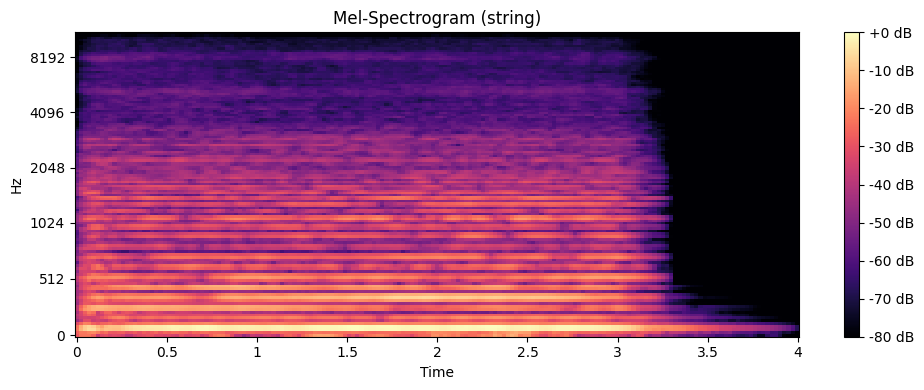

In [10]:
plt.figure(figsize=(10,4))
librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title(f"Mel-Spectrogram ({instrument})")
plt.tight_layout()
plt.show()


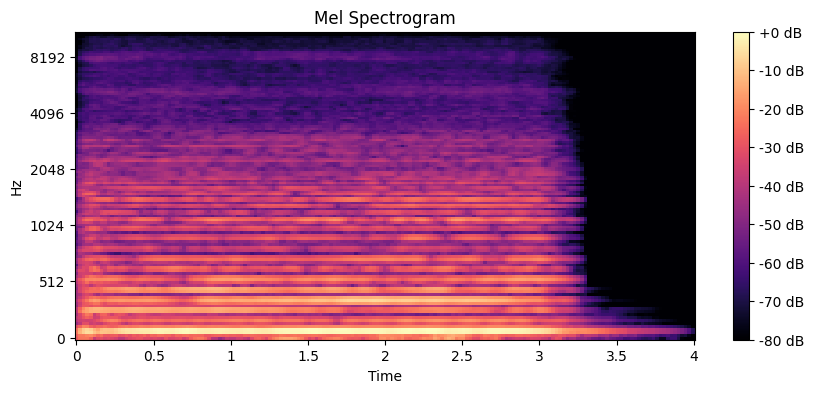

In [11]:
plt.figure(figsize=(10,4))
librosa.display.specshow(mel_db, sr=22050, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.show()


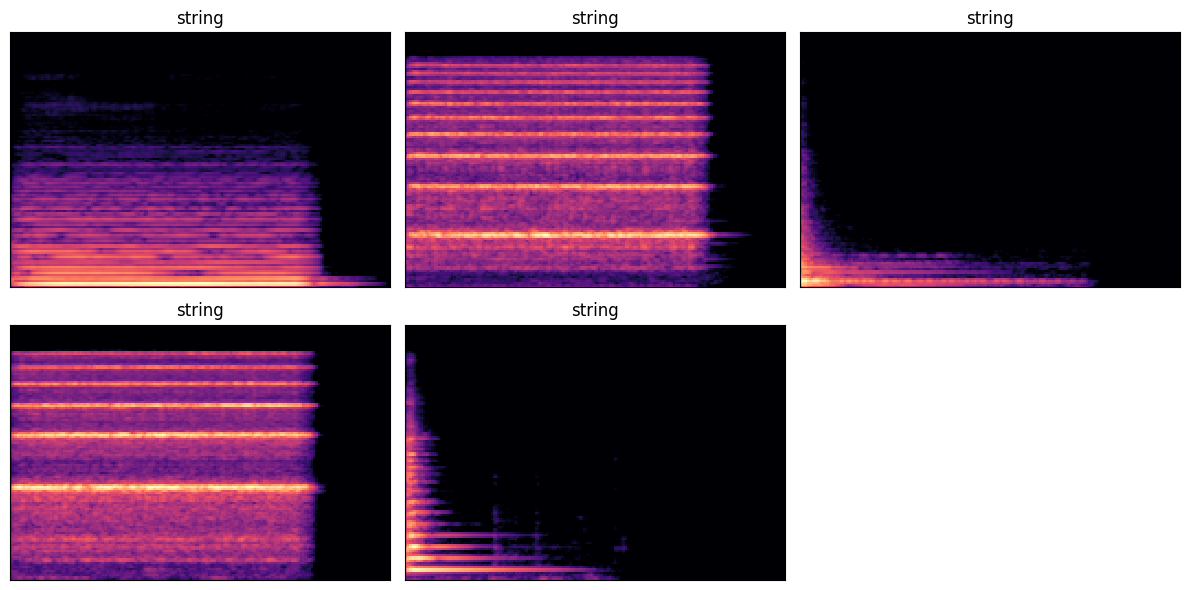

In [12]:
plt.figure(figsize=(12,6))

for i in range(5):
    file_name = random.choice(instrument_files[instrument])
    file_path = os.path.join(AUDIO_PATH, file_name)

    y, _ = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
    y = librosa.util.fix_length(y, size=SAMPLES)

    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    plt.subplot(2,3,i+1)
    librosa.display.specshow(mel_db, sr=sr, x_axis=None, y_axis=None)
    plt.title(instrument)

plt.tight_layout()
plt.show()


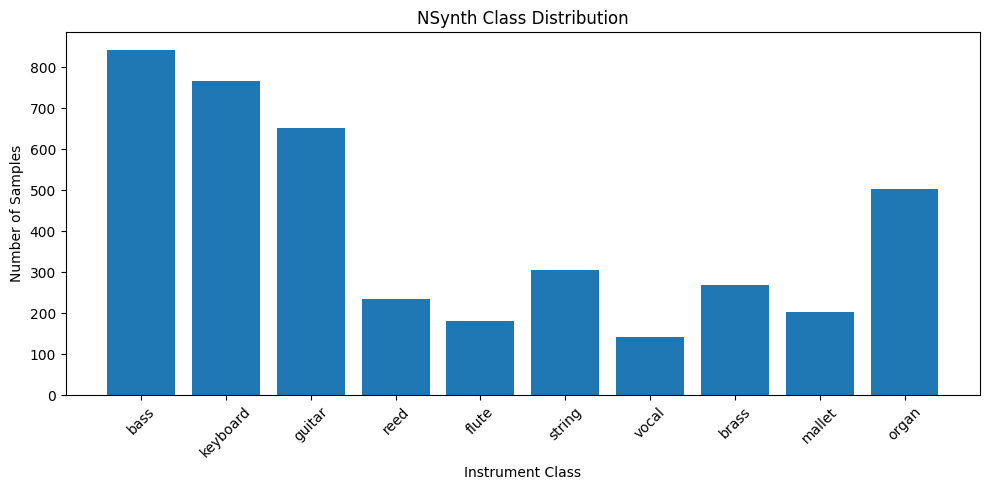

In [13]:
classes = list(instrument_files.keys())
counts = [len(instrument_files[c]) for c in classes]

plt.figure(figsize=(10,5))
plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.xlabel("Instrument Class")
plt.ylabel("Number of Samples")
plt.title("NSynth Class Distribution")
plt.tight_layout()
plt.show()

In [14]:
instrument_family_files = {}

for key, value in metadata.items():
    family = value["instrument_family_str"]
    filename = key + ".wav"

    if family not in instrument_family_files:
        instrument_family_files[family] = []

    instrument_family_files[family].append(filename)


In [17]:
SAMPLE_RATE = 22050
DURATION = 4
SAMPLES = SAMPLE_RATE * DURATION
MAX_FILES_PER_CLASS = 20  # keep small for speed

boxplot_data = {}

for family, files in instrument_family_files.items():
    intensities = []

    selected_files = random.sample(files, min(len(files), MAX_FILES_PER_CLASS))

    for file_name in selected_files:
        file_path = os.path.join(AUDIO_PATH, file_name)

        try:
            y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
            y = librosa.util.fix_length(y, size=SAMPLES)

            mel = librosa.feature.melspectrogram(y=y, sr=sr)
            mel_db = librosa.power_to_db(mel, ref=np.max)

            intensities.extend(mel_db.flatten())

        except Exception as e:
            continue

    if len(intensities) > 0:
        boxplot_data[family] = intensities


/tmp/ipython-input-3367941363.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


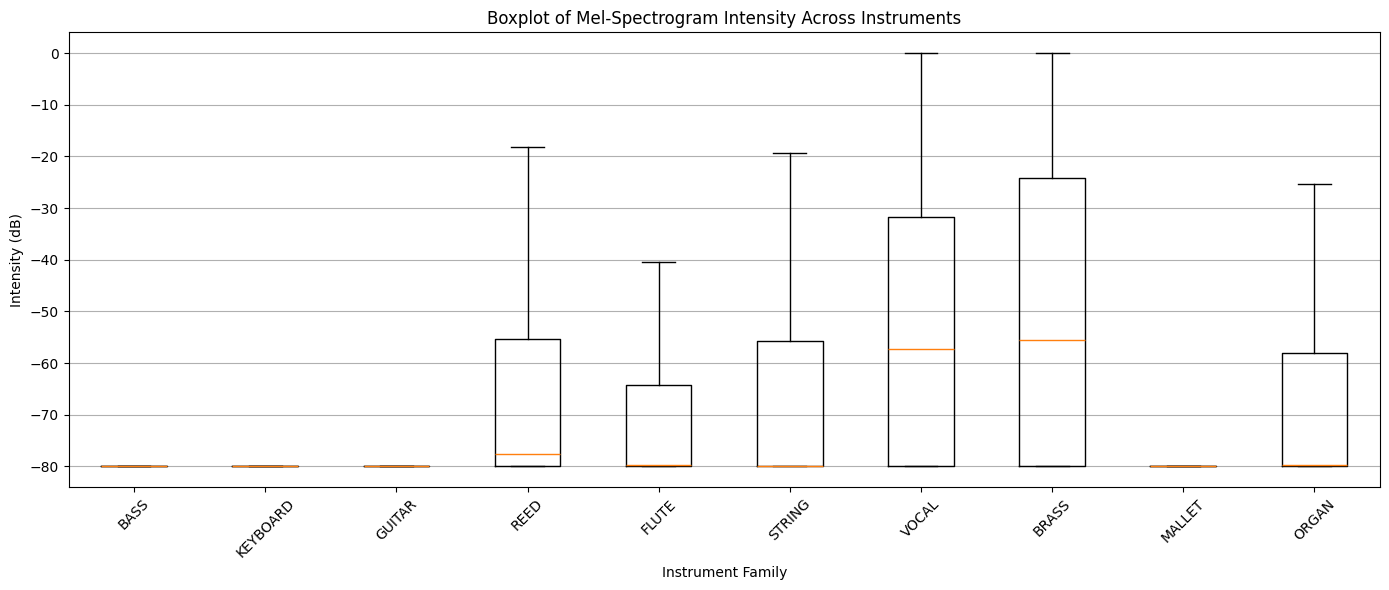

In [18]:
plt.figure(figsize=(14, 6))

plt.boxplot(
    boxplot_data.values(),
    labels=[k.upper() for k in boxplot_data.keys()],
    showfliers=False
)

plt.title("Boxplot of Mel-Spectrogram Intensity Across Instruments")
plt.ylabel("Intensity (dB)")
plt.xlabel("Instrument Family")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.tight_layout()
plt.show()


In [19]:
OUTPUT_DIR = "/content/drive/MyDrive/processed_spectrograms"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.listdir(OUTPUT_DIR)


['bass',
 'keyboard',
 'guitar',
 'reed',
 'flute',
 'string',
 'vocal',
 'brass',
 'mallet',
 'organ']

In [20]:
for family in instrument_family_files.keys():
    os.makedirs(os.path.join(OUTPUT_DIR, family), exist_ok=True)


In [21]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import random

SAMPLE_RATE = 22050
DURATION = 4
SAMPLES = SAMPLE_RATE * DURATION
MAX_FILES_PER_CLASS = 5  # small number for demo

for family, files in instrument_family_files.items():
    selected_files = random.sample(files, min(len(files), MAX_FILES_PER_CLASS))

    for idx, file_name in enumerate(selected_files):
        file_path = os.path.join(AUDIO_PATH, file_name)

        y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
        y = librosa.util.fix_length(y, size=SAMPLES)
        mel_db = librosa.power_to_db(mel, ref=1.0)
        mel_db = np.nan_to_num(mel_db)

        plt.figure(figsize=(3,3))
        librosa.display.specshow(mel_db, sr=sr)
        plt.axis("off")

        save_path = os.path.join(
            OUTPUT_DIR, family, f"{family}_{idx}.png"
        )
        plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
        plt.close()


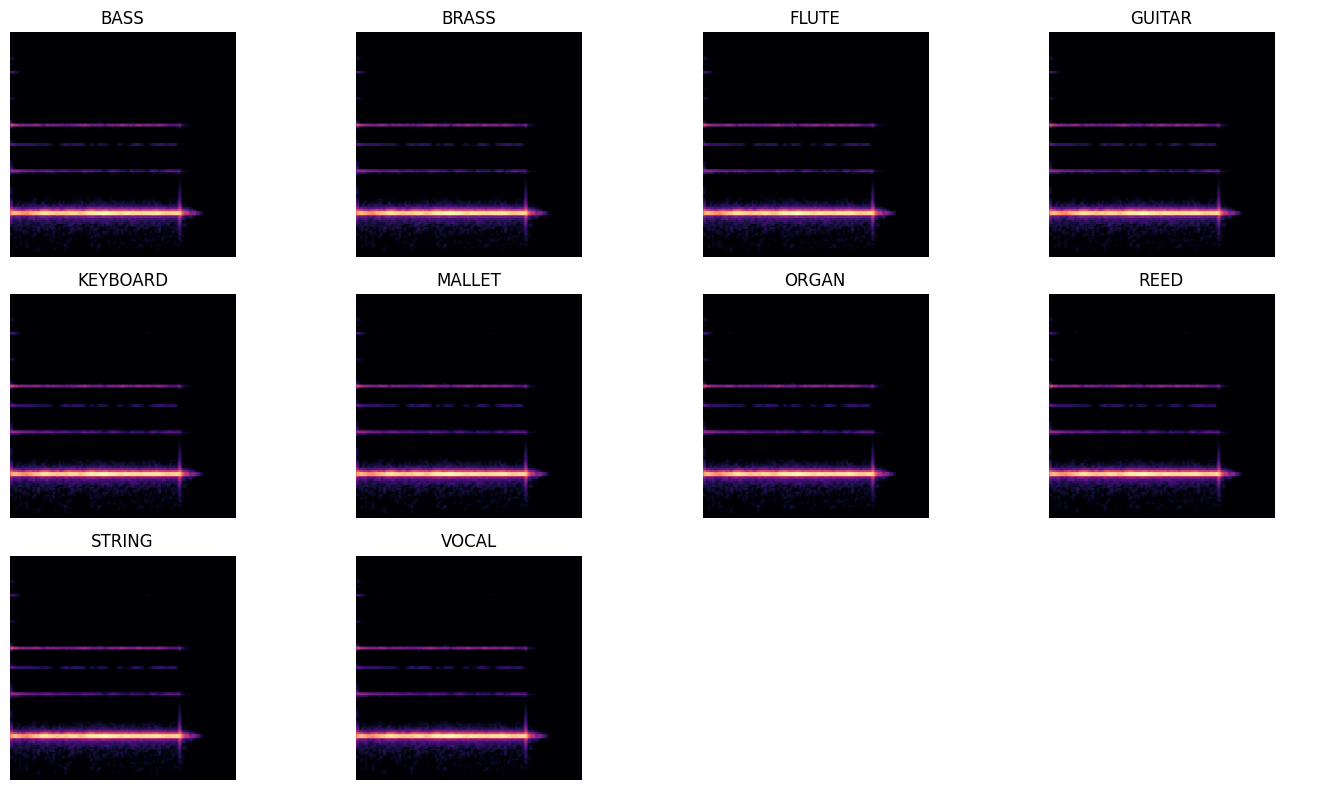

In [22]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4, figsize=(14, 8))
axes = axes.flatten()

i = 0
for instrument in sorted(os.listdir(OUTPUT_DIR)):
    img_folder = os.path.join(OUTPUT_DIR, instrument)

    if not os.path.isdir(img_folder):
        continue

    images = os.listdir(img_folder)
    if len(images) == 0:
        continue

    img_path = os.path.join(img_folder, images[0])
    img = plt.imread(img_path)

    axes[i].imshow(img)
    axes[i].set_title(instrument.upper())
    axes[i].axis("off")
    i += 1

for j in range(i, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


MILESTONE 2

In [23]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
AUDIO_PATH = "/content/drive/MyDrive/nsynth-test/audio"
JSON_PATH  = "/content/drive/MyDrive/nsynth-test/examples.json"


In [25]:
import json

with open(JSON_PATH, "r") as f:
    metadata = json.load(f)

instrument_family_map = {
    0: "bass",
    1: "brass",
    2: "flute",
    3: "guitar",
    4: "keyboard",
    5: "mallet",
    6: "organ",
    7: "reed",
    8: "string",
    9: "vocal"
}

In [26]:
X, y = [], []

MAX_PER_CLASS = 500
counts = {v: 0 for v in instrument_family_map.values()}

In [27]:
X = []
y = []

SAMPLE_RATE = 22050
DURATION = 3
MAX_PER_CLASS = 500

counts = {v: 0 for v in instrument_family_map.values()}

for file_name, info in metadata.items():

    family_id = info["instrument_family"]

    if family_id not in instrument_family_map:
        continue

    family = instrument_family_map[family_id]

    if counts[family] >= MAX_PER_CLASS:
        continue

    file_path = os.path.join(AUDIO_PATH, file_name + ".wav")
    if not os.path.exists(file_path):
        continue

    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True, duration=DURATION)

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel, ref=1.0)

    # 🔥 IMPORTANT FIX
    mel_db = np.nan_to_num(mel_db)

    mel_db = librosa.util.fix_length(mel_db, size=128, axis=1)

    X.append(mel_db)
    y.append(family)

    counts[family] += 1

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)


Dataset shape: (3192, 128, 128)


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical


In [29]:
print("Original Shape:", X.shape)

# Add channel dimension (ONLY ONCE)
X = np.expand_dims(X, axis=-1)

print("After Channel Add:", X.shape)


Original Shape: (3192, 128, 128)
After Channel Add: (3192, 128, 128, 1)


In [30]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_classes = len(np.unique(y_encoded))

y_onehot = to_categorical(y_encoded, num_classes)


In [31]:
X_train, X_test, y_train_onehot, y_test_onehot = train_test_split(
    X, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_onehot
)


In [32]:
X_train = X_train / np.max(X_train)
X_test  = X_test / np.max(X_test)

print("Train Shape:", X_train.shape)
print("Any NaN:", np.isnan(X_train).any())


Train Shape: (2553, 128, 128, 1)
Any NaN: False


In [33]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [36]:
history = model.fit(
    X_train,
    y_train_onehot,
    validation_data=(X_test, y_test_onehot),
    epochs=20,        # reduced from 30 → 20
    batch_size=32
)



Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.3505 - loss: 2.8439 - val_accuracy: 0.2175 - val_loss: 2.0812
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.5704 - loss: 1.2345 - val_accuracy: 0.3099 - val_loss: 2.1037
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.6781 - loss: 0.9215 - val_accuracy: 0.3865 - val_loss: 2.2137
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.7465 - loss: 0.6674 - val_accuracy: 0.5117 - val_loss: 1.8454
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8234 - loss: 0.4891 - val_accuracy: 0.6526 - val_loss: 1.1063
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.8667 - loss: 0.3979 - val_accuracy: 0.7574 - val_loss: 0.8505
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.8894 - loss: 0.3215 - val_accuracy: 0.8905 - val_loss: 0.3332
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.8818 - loss: 0.2971 - val_accuracy: 0.8858 - v

In [37]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])


Final Training Accuracy: 0.9600470066070557
Final Validation Accuracy: 0.964006245136261


In [38]:
y_true = np.argmax(y_test_onehot, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Test Accuracy:", accuracy_score(y_true, y_pred))


20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 370ms/step
Test Accuracy: 0.9640062597809077


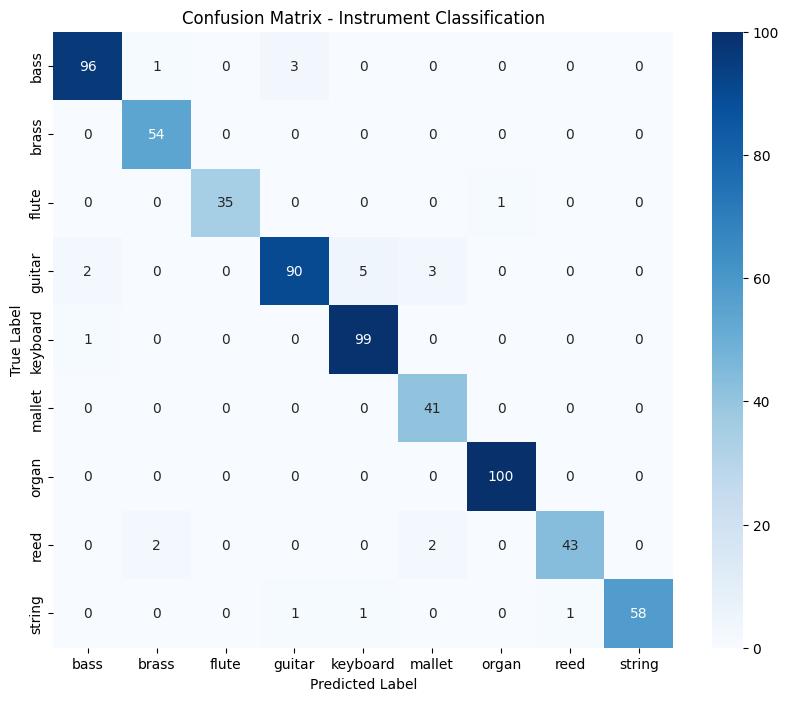

In [39]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Instrument Classification")
plt.show()


In [40]:
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))


              precision    recall  f1-score   support

        bass       0.97      0.96      0.96       100
       brass       0.95      1.00      0.97        54
       flute       1.00      0.97      0.99        36
      guitar       0.96      0.90      0.93       100
    keyboard       0.94      0.99      0.97       100
      mallet       0.89      1.00      0.94        41
       organ       0.99      1.00      1.00       100
        reed       0.98      0.91      0.95        47
      string       1.00      0.95      0.97        61

    accuracy                           0.96       639
   macro avg       0.96      0.97      0.96       639
weighted avg       0.97      0.96      0.96       639



MILESTONE 3

In [41]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_onehot, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 254ms/step - accuracy: 0.9687 - loss: 0.1131
Test Loss: 0.11598776280879974
Test Accuracy: 0.964006245136261


In [46]:
def build_model(filters=32, kernel_size=(3,3)):
    model = Sequential([
        Conv2D(filters, kernel_size, activation='relu', input_shape=X_train.shape[1:]),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(filters*2, kernel_size, activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
configs = [
    (32, (3,3)),
    (64, (3,3)),
    (32, (5,5))
]

for filters, kernel in configs:
    print(f"\nFilters: {filters}, Kernel: {kernel}")

    temp_model = build_model(filters, kernel)
    history = temp_model.fit(
        X_train, y_train_onehot,
        validation_data=(X_test, y_test_onehot),
        epochs=10,
        batch_size=32,
        verbose=0
    )

    print("Best Val Accuracy:", max(history.history["val_accuracy"]))

In [ ]:
# Multi-label output layer
Dense(num_classes, activation='sigmoid')

# Compile with binary crossentropy
model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


MILESTONE 3

In [49]:
test_loss, test_acc = model.evaluate(X_test, y_test_onehot)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_acc)


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 246ms/step - accuracy: 0.9687 - loss: 0.1131
Test Loss : 0.11598776280879974
Test Accuracy : 0.964006245136261


In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model_tuned = Sequential([

    Input(shape=X_train.shape[1:]),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(y_train_onehot.shape[1], activation='softmax')
])

model_tuned.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_tuned.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 126, 126, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 61, 61, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,219,081 (50.43 MB)

 Trainable params: 13,218,185 (50.42 MB)

 Non-trainable params: 896 (3.50 KB)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 207ms/step


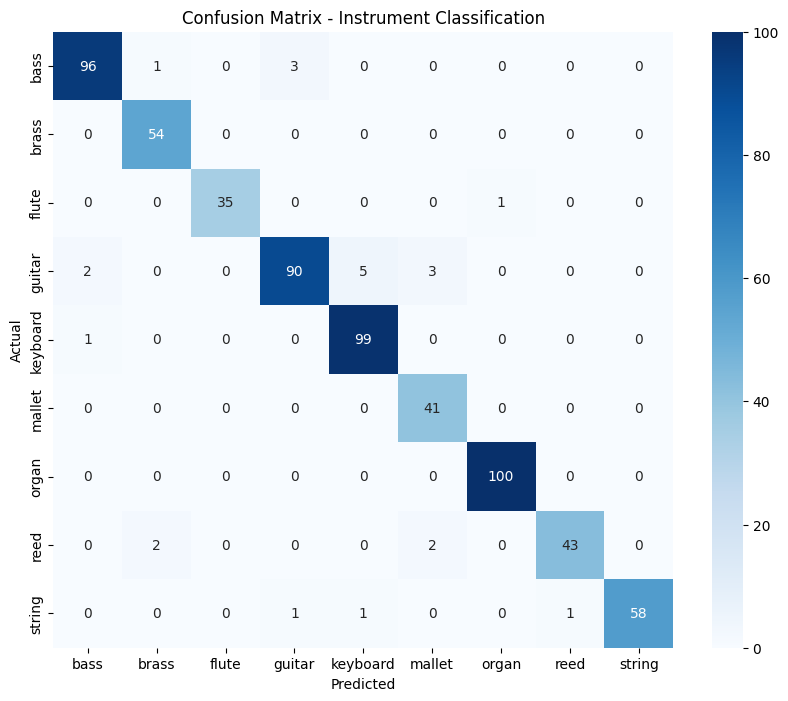

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Instrument Classification")
plt.show()


In [52]:
from sklearn.metrics import classification_report, accuracy_score

acc = accuracy_score(y_true, y_pred)
print("Final Accuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred,
                            target_names=label_encoder.classes_))


Final Accuracy: 0.9640062597809077

Classification Report:

              precision    recall  f1-score   support

        bass       0.97      0.96      0.96       100
       brass       0.95      1.00      0.97        54
       flute       1.00      0.97      0.99        36
      guitar       0.96      0.90      0.93       100
    keyboard       0.94      0.99      0.97       100
      mallet       0.89      1.00      0.94        41
       organ       0.99      1.00      1.00       100
        reed       0.98      0.91      0.95        47
      string       1.00      0.95      0.97        61

    accuracy                           0.96       639
   macro avg       0.96      0.97      0.96       639
weighted avg       0.97      0.96      0.96       639



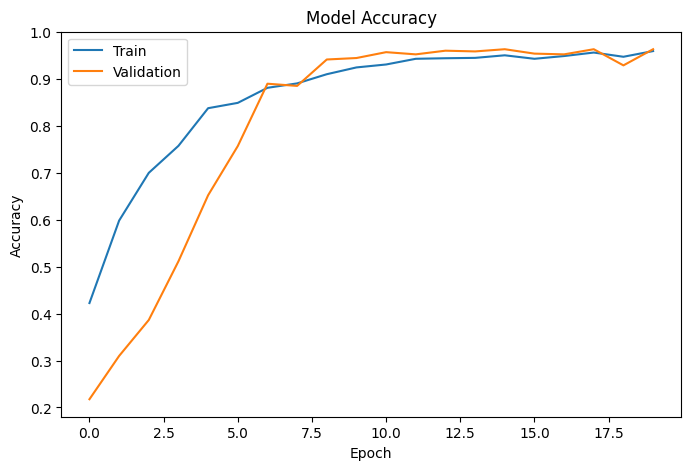

In [53]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


In [54]:
X_train = np.squeeze(X_train)
X_test  = np.squeeze(X_test)

# Add channel dimension back
X_train = np.expand_dims(X_train, axis=-1)
X_test  = np.expand_dims(X_test, axis=-1)

print("Fixed shape:", X_train.shape)


Fixed shape: (2553, 128, 128, 1)


In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model_tuned = Sequential([

    Input(shape=X_train.shape[1:]),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(y_train_onehot.shape[1], activation='softmax')
])

model_tuned.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_tuned.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 126, 126, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 61, 61, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,219,081 (50.43 MB)

 Trainable params: 13,218,185 (50.42 MB)

 Non-trainable params: 896 (3.50 KB)

In [56]:
history_tuned = model_tuned.fit(
    X_train,
    y_train_onehot,
    validation_data=(X_test, y_test_onehot),
    epochs=20,
    batch_size=32
)


Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 356s 4s/step - accuracy: 0.4059 - loss: 3.3190 - val_accuracy: 0.1565 - val_loss: 4.9169
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 394s 5s/step - accuracy: 0.7283 - loss: 0.8145 - val_accuracy: 0.1565 - val_loss: 7.1373
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 372s 4s/step - accuracy: 0.8353 - loss: 0.5473 - val_accuracy: 0.2520 - val_loss: 5.9679
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 363s 5s/step - accuracy: 0.8680 - loss: 0.3983 - val_accuracy: 0.3208 - val_loss: 4.0640
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 382s 5s/step - accuracy: 0.8971 - loss: 0.3071 - val_accuracy: 0.4883 - val_loss: 1.9494
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 351s 4s/step - accuracy: 0.9422 - loss: 0.1811 - val_accuracy: 0.6588 - val_loss: 1.1547
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 355s 4s/step - accuracy: 0.9367 - loss: 0.1962 - val_accuracy: 0.8404 - val_loss: 0.4895
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 377s 4s/step - accuracy: 0.9480 - loss: 0.1519 - val_accuracy: 0.9390 - v

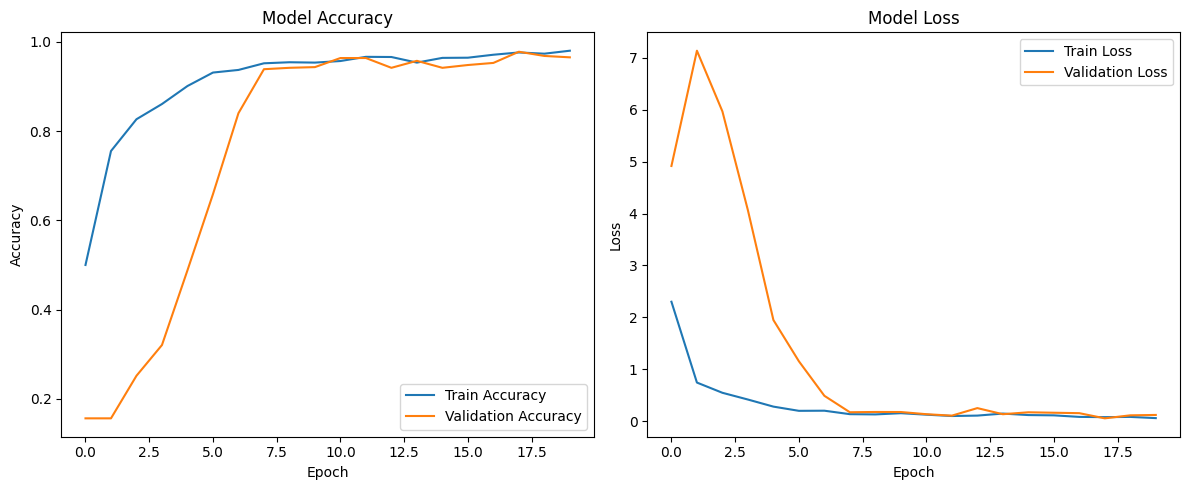

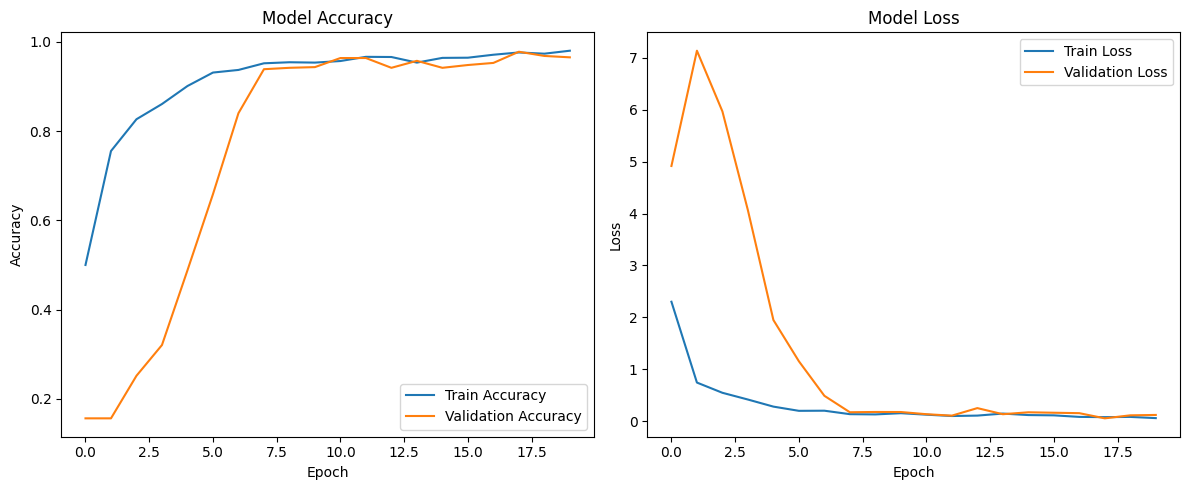

In [58]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_tuned.history['accuracy'], label='Train Accuracy')
plt.plot(history_tuned.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history_tuned.history['loss'], label='Train Loss')
plt.plot(history_tuned.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [59]:
print("Final Training Accuracy:", history_tuned.history['accuracy'][-1])
print("Final Validation Accuracy:", history_tuned.history['val_accuracy'][-1])
print("Final Training Loss:", history_tuned.history['loss'][-1])
print("Final Validation Loss:", history_tuned.history['val_loss'][-1])


Final Training Accuracy: 0.9804152250289917
Final Validation Accuracy: 0.9655712246894836
Final Training Loss: 0.05967051908373833
Final Validation Loss: 0.12086528539657593


In [62]:
model_tuned.save("/content/instrument_model.h5")


In [64]:
from google.colab import files
files.download("/content/instrument_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>